# Fine motor study: review and exploratory analysis

This notebook reviews acquired trials for **control vs disease**, under `normal_dom`, `normal_ndom`, `blind_dom`, and `blind_ndom`. Run from top to bottom, then edit the configuration and rerun as needed. `main.ipynb` acquires data; the Python modules beside it implement analysis and replay.

**Task:** start with hands at rest at shoulder width, pick up a lock and key, unlock it, then return to rest.

**What the data can tell us:** wrist-relative fingertip movement, thumb–index spacing, movement variability, and acquisition quality. Without a specified target/task, dispersion is **not target error or a validated precision score**. Intentional movement, hand rotation, camera noise, and tracking error all contribute. These outputs are exploratory study summaries, not a diagnostic classifier.

The saved x/y positions are normalized image coordinates; z is estimated depth relative to the wrist, not a calibrated physical point cloud. No millimetres or absolute 3D speed are inferred. See [MediaPipe coordinates](https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/python).


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from proj.session import DEFAULT_DATA_DIR
from proj.review_data import discover_trials, prepare_group_file
from proj.motor_metrics import extract_metrics, PRIMARY_METRICS, METRICS
from proj.study_statistics import (
    subject_summary, descriptive_statistics, compare_groups, paired_condition_effects, balanced_overall_summary,
)
from proj.review_plots import plot_group_distributions, plot_paired_conditions, display_figure_once
from proj.landmark_replay import review_widget
from proj.task_analysis import add_task_metrics, TASK_OUTCOMES, outcome_counts

DATA_DIR = DEFAULT_DATA_DIR
EXPORT_DIR = DATA_DIR.parent / "analysis_exports"

# Optional overrides; dominant hand is normally loaded from recording metadata/subject CSV.
# Example: {"Alice": "right", "Bob": "left"}
DOMINANT_HANDS = {}
# Override a specific trial if needed: {"Alice/trial_folder": "right"}
HAND_OVERRIDES = {}
# Legacy CSV hand indices are not stable identities. Enable only after visual review.
ALLOW_LEGACY_HAND_INDEX = False
LEGACY_IMAGE_SIZE = None  # e.g. (640, 480), only if these were the actual capture dimensions

# Pre-specify quality thresholds and outcomes before inspecting group differences.
MIN_FRAMES = 30
MIN_COVERAGE = 0.8
MIN_DURATION_SECONDS = 1.0
MIN_HANDEDNESS_CONFIDENCE = 0.6
MAX_DERIVATIVE_GAP_SECONDS = 0.25
OUTCOMES = list(TASK_OUTCOMES)
WHOLE_TRIAL_OUTCOMES = ["recording_duration_seconds", *METRICS]
SUCCESSFUL_TASKS_ONLY = True  # Success is assumed for the single-event protocol.
MIN_REST_PHASE_FRAMES = 10


## 1. Recordings and group assignment

New recordings prompt once for `control` or `disease` and also ask which hand is dominant, and save both in metadata and `data/subject_groups.csv`. The CSV has `subject_name`, `group`, and `dominant_hand` columns; use `left` or `right` for handedness. For old recordings, this cell creates a subject/group template. Edit its blank group cells, save, and rerun this cell. The registry takes precedence over trial metadata, so any corrected assignment applies consistently to all that subject's trials. Unassigned subjects are visible for review but excluded from group inference. Subject names are matched exactly.

Cancelled/interrupted recordings remain in the inventory but are excluded from analysis. Existing directories in both naming schemes are discovered.


In [2]:
inventory = discover_trials(DATA_DIR)
group_file = prepare_group_file(inventory, DATA_DIR)
inventory = discover_trials(DATA_DIR)
print(f"Group registry: {group_file}")
print(f"Found {len(inventory)} trials, {inventory.subject_name.nunique()} subjects.")
display(inventory)
if inventory.empty:
    print("No acquired trials yet. Record with main.ipynb, then rerun this notebook.")
else:
    display(inventory.groupby(["group", "experiment_type", "status"], dropna=False).size().rename("trials").reset_index())
    missing_groups = inventory.loc[inventory.group == "", "subject_name"].unique()
    if len(missing_groups):
        print(f"Assign groups in the registry: {list(missing_groups)}")


Group registry: /home/jakub/Projects/proj/data/subject_groups.csv
Found 32 trials, 8 subjects.


,trial_id,subject_name,group,experiment_type,status,frames_recorded,duration_seconds,dominant_hand,csv_path,metadata_path,error
0,Elena/blind_dom_2026-10-07_16-20-50_742105,Elena,control,blind_dom,completed,243,10.101178,right,/home/jakub/Projects/proj/data/Elena/blind_dom...,/home/jakub/Projects/proj/data/Elena/blind_dom...,
1,Elena/blind_ndom_2026-10-07_16-20-32_040469,Elena,control,blind_ndom,completed,157,6.547583,right,/home/jakub/Projects/proj/data/Elena/blind_ndo...,/home/jakub/Projects/proj/data/Elena/blind_ndo...,
2,Elena/normal_dom_2026-10-07_16-20-13_904486,Elena,control,normal_dom,completed,125,5.213980,right,/home/jakub/Projects/proj/data/Elena/normal_do...,/home/jakub/Projects/proj/data/Elena/normal_do...,
3,Elena/normal_ndom_2026-10-07_16-19-03_281416,Elena,control,normal_ndom,completed,134,5.553500,right,/home/jakub/Projects/proj/data/Elena/normal_nd...,/home/jakub/Projects/proj/data/Elena/normal_nd...,
4,Katharina/blind_dom_2026-10-07_16-41-17_944735,Katharina,control,blind_dom,completed,153,6.356821,right,/home/jakub/Projects/proj/data/Katharina/blind...,/home/jakub/Projects/proj/data/Katharina/blind...,
5,Katharina/blind_ndom_2026-10-07_16-40-35_745860,Katharina,control,blind_ndom,completed,245,10.231811,right,/home/jakub/Projects/proj/data/Katharina/blind...,/home/jakub/Projects/proj/data/Katharina/blind...,
6,Katharina/normal_dom_2026-10-07_16-38-40_830466,Katharina,control,normal_dom,completed,132,5.548403,right,/home/jakub/Projects/proj/data/Katharina/norma...,/home/jakub/Projects/proj/data/Katharina/norma...,
7,Katharina/normal_ndom_2026-10-07_16-41-02_042205,Katharina,control,normal_ndom,completed,140,5.798106,right,/home/jakub/Projects/proj/data/Katharina/norma...,/home/jakub/Projects/proj/data/Katharina/norma...,
8,Lisa-Marie/blind_dom_2026-10-07_15-54-51_777434,Lisa-Marie,control,blind_dom,completed,123,5.208601,right,/home/jakub/Projects/proj/data/Lisa-Marie/blin...,/home/jakub/Projects/proj/data/Lisa-Marie/blin...,
9,Lisa-Marie/blind_ndom_2026-10-07_15-55-40_446473,Lisa-Marie,control,blind_ndom,completed,131,5.455849,right,/home/jakub/Projects/proj/data/Lisa-Marie/blin...,/home/jakub/Projects/proj/data/Lisa-Marie/blin...,


,group,experiment_type,status,trials
0,control,blind_dom,completed,5
1,control,blind_ndom,completed,5
2,control,normal_dom,completed,5
3,control,normal_ndom,completed,5
4,disease,blind_dom,completed,3
5,disease,blind_ndom,completed,3
6,disease,normal_dom,completed,3
7,disease,normal_ndom,completed,3


## 2. Quality and movement features

Choose the **task hand**, not detection index 0/1. Dominant hand comes from `subject_groups.csv` or recording metadata; `DOMINANT_HANDS` can override it. The `_dom`/`_ndom` condition selects the corresponding hand. Otherwise, auto-selection is allowed only when exactly one anatomical label is present. Ambiguous labels and low-confidence detections are excluded. Legacy indices require explicit opt-in because hand identity may switch.

Measurements use the 2D index fingertip relative to the wrist, correcting y for image aspect ratio. All distances use the trial's median wrist-to-middle-MCP length as a fixed scale:

- `tip_dispersion_rms`: RMS distance of the relative tip from its trial centroid (palm lengths). Appropriate as a variability measure; it mixes intentional movement with instability.
- `pinch_sd`: sample SD of thumb–index spacing (palm lengths). Also affected by the task's intentional opening/closing.
- `pinch_mean`: mean thumb–index spacing.
- `tip_speed_mean`: time-weighted relative fingertip speed (palm lengths/s).
- `tip_path_length`: summed relative motion over consecutive valid frames (palm lengths); strongly depends on trial duration.

Derivatives never bridge missing frames or long time gaps. No smoothing or tremor-frequency claim is made. Coverage measures selected-hand detections / recorded frames. New recordings save image dimensions and handedness; legacy recordings need known camera dimensions before computing metrics. Whole-trial motion features remain exploratory descriptors. Event outcomes are time from recording start to key insertion, time after insertion to recording end, and whole-trial duration. These include operator reaction/marking time and are not isolated unlocking duration. Thresholds are configurable and are not clinically validated cutoffs.

### Single event: key is in the lock

Space starts the countdown, then records **key is in the lock**, then finishes the trial and loads the next one. Only insertion is logged as an event. Success is assumed; there is no success/failure prompt. The time is saved in `task_annotations.json` and metadata as `key_in_lock_seconds`.

The event comes from the operator's key press, not landmark-based inference. For older trials or corrections, enter its time in the replay controls. Earlier four-phase recordings remain readable, but their phase markers are not reinterpreted as key insertion. Missing insertion times remain unavailable.


In [3]:
hand_selections = dict(HAND_OVERRIDES)
for _, trial in inventory.iterrows():
    dominant = DOMINANT_HANDS.get(trial.subject_name) or trial.dominant_hand
    if dominant:
        if dominant not in ("left", "right"):
            raise ValueError("DOMINANT_HANDS values must be left or right")
        selected = ("left" if dominant == "right" else "right") if trial.experiment_type.endswith("_ndom") else dominant
        hand_selections.setdefault(trial.trial_id, selected)

trial_metrics = extract_metrics(
    inventory, hand_selections=hand_selections,
    allow_legacy=ALLOW_LEGACY_HAND_INDEX, legacy_image_size=LEGACY_IMAGE_SIZE,
    min_frames=MIN_FRAMES, min_coverage=MIN_COVERAGE,
    min_duration_seconds=MIN_DURATION_SECONDS,
    min_confidence=MIN_HANDEDNESS_CONFIDENCE,
    max_gap_seconds=MAX_DERIVATIVE_GAP_SECONDS,
)
trial_metrics = add_task_metrics(
    trial_metrics, hand_selections=hand_selections,
    allow_legacy=ALLOW_LEGACY_HAND_INDEX, legacy_image_size=LEGACY_IMAGE_SIZE,
    min_confidence=MIN_HANDEDNESS_CONFIDENCE,
    max_gap_seconds=MAX_DERIVATIVE_GAP_SECONDS, min_phase_frames=MIN_REST_PHASE_FRAMES,
)
display(trial_metrics)
display(trial_metrics[["trial_id", "annotation_status", "task_outcome", "phase_quality_note", *TASK_OUTCOMES]])
display(outcome_counts(trial_metrics))
display(trial_metrics.loc[~trial_metrics.analysis_eligible,
    ["trial_id", "status", "selected_hand", "detection_coverage", "exclusion_reason"]])
print(f"Eligible trials: {int(trial_metrics.analysis_eligible.sum())} / {len(trial_metrics)}")


,trial_id,subject_name,group,experiment_type,status,frames_recorded,duration_seconds,dominant_hand,csv_path,metadata_path,...,pickup_duration_seconds,return_duration_seconds,initial_rest_duration_seconds,final_rest_duration_seconds,initial_rest_frames,final_rest_frames,task_success,task_outcome,annotation_status,phase_quality_note
0,Elena/blind_dom_2026-10-07_16-20-50_742105,Elena,control,blind_dom,completed,243,10.101178,right,/home/jakub/Projects/proj/data/Elena/blind_dom...,/home/jakub/Projects/proj/data/Elena/blind_dom...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
1,Elena/blind_ndom_2026-10-07_16-20-32_040469,Elena,control,blind_ndom,completed,157,6.547583,right,/home/jakub/Projects/proj/data/Elena/blind_ndo...,/home/jakub/Projects/proj/data/Elena/blind_ndo...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
2,Elena/normal_dom_2026-10-07_16-20-13_904486,Elena,control,normal_dom,completed,125,5.213980,right,/home/jakub/Projects/proj/data/Elena/normal_do...,/home/jakub/Projects/proj/data/Elena/normal_do...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
3,Elena/normal_ndom_2026-10-07_16-19-03_281416,Elena,control,normal_ndom,completed,134,5.553500,right,/home/jakub/Projects/proj/data/Elena/normal_nd...,/home/jakub/Projects/proj/data/Elena/normal_nd...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
4,Katharina/blind_dom_2026-10-07_16-41-17_944735,Katharina,control,blind_dom,completed,153,6.356821,right,/home/jakub/Projects/proj/data/Katharina/blind...,/home/jakub/Projects/proj/data/Katharina/blind...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
5,Katharina/blind_ndom_2026-10-07_16-40-35_745860,Katharina,control,blind_ndom,completed,245,10.231811,right,/home/jakub/Projects/proj/data/Katharina/blind...,/home/jakub/Projects/proj/data/Katharina/blind...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
6,Katharina/normal_dom_2026-10-07_16-38-40_830466,Katharina,control,normal_dom,completed,132,5.548403,right,/home/jakub/Projects/proj/data/Katharina/norma...,/home/jakub/Projects/proj/data/Katharina/norma...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
7,Katharina/normal_ndom_2026-10-07_16-41-02_042205,Katharina,control,normal_ndom,completed,140,5.798106,right,/home/jakub/Projects/proj/data/Katharina/norma...,/home/jakub/Projects/proj/data/Katharina/norma...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
8,Lisa-Marie/blind_dom_2026-10-07_15-54-51_777434,Lisa-Marie,control,blind_dom,completed,123,5.208601,right,/home/jakub/Projects/proj/data/Lisa-Marie/blin...,/home/jakub/Projects/proj/data/Lisa-Marie/blin...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,
9,Lisa-Marie/blind_ndom_2026-10-07_15-55-40_446473,Lisa-Marie,control,blind_ndom,completed,131,5.455849,right,/home/jakub/Projects/proj/data/Lisa-Marie/blin...,/home/jakub/Projects/proj/data/Lisa-Marie/blin...,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,success,annotated,


,trial_id,annotation_status,task_outcome,phase_quality_note,time_to_key_seconds,post_key_duration_seconds,recording_duration_seconds
0,Elena/blind_dom_2026-10-07_16-20-50_742105,annotated,success,,6.820210,3.280968,10.101178
1,Elena/blind_ndom_2026-10-07_16-20-32_040469,annotated,success,,2.237140,4.310443,6.547583
2,Elena/normal_dom_2026-10-07_16-20-13_904486,annotated,success,,1.725507,3.488474,5.213980
3,Elena/normal_ndom_2026-10-07_16-19-03_281416,annotated,success,,1.715231,3.838269,5.553500
4,Katharina/blind_dom_2026-10-07_16-41-17_944735,annotated,success,,3.389671,2.967151,6.356821
5,Katharina/blind_ndom_2026-10-07_16-40-35_745860,annotated,success,,4.672038,5.559773,10.231811
6,Katharina/normal_dom_2026-10-07_16-38-40_830466,annotated,success,,2.495028,3.053375,5.548403
7,Katharina/normal_ndom_2026-10-07_16-41-02_042205,annotated,success,,4.506549,1.291557,5.798106
8,Lisa-Marie/blind_dom_2026-10-07_15-54-51_777434,annotated,success,,2.550001,2.658601,5.208601
9,Lisa-Marie/blind_ndom_2026-10-07_15-55-40_446473,annotated,success,,3.202108,2.253741,5.455849


,group,experiment_type,task_outcome,trials
0,control,blind_dom,success,5
1,control,blind_ndom,success,5
2,control,normal_dom,success,5
3,control,normal_ndom,success,5
4,disease,blind_dom,success,3
5,disease,blind_ndom,success,3
6,disease,normal_dom,success,3
7,disease,normal_ndom,success,3


,trial_id,status,selected_hand,detection_coverage,exclusion_reason
22,Yoconda1/normal_dom_2026-10-07_16-36-21_841507,completed,right,0.769784,Detection coverage below 80%


Eligible trials: 31 / 32


## Whole-trial statistics and overall group summary

The per-trial table summarizes the entire CSV recording: total recording duration, selected-hand frames, coverage, fingertip dispersion, pinch mean/SD, relative speed, and path length. Whole-trial duration includes initial/final rest and operator waiting; active task duration is reported separately above. Whole-trial motion is an exploratory descriptor, not lock alignment error.

Control/disease descriptive statistics and comparisons below use one averaged trial value per subject and condition, with the same quality checks. They do **not** require phase annotations or a known success label. Cancelled/interrupted trials stay visible in the trial table but are excluded from inference.

The overall summary gives equal weight to the four condition means for each subject. Only subjects with all four eligible conditions contribute, preventing unequal condition mixtures between groups. A metric remains unavailable unless all four condition values exist. Holm correction is applied separately to the whole-trial condition comparisons and the overall comparisons.


In [4]:
whole_trial_table = trial_metrics[[
    "trial_id", "subject_name", "group", "experiment_type", "status",
    "recording_duration_seconds", "frames_recorded", "selected_frames",
    "detection_coverage", *METRICS, "analysis_eligible", "exclusion_reason",
]]
display(whole_trial_table)
whole_trial_subjects = subject_summary(trial_metrics, metrics=WHOLE_TRIAL_OUTCOMES)
whole_trial_descriptives = descriptive_statistics(whole_trial_subjects, metrics=WHOLE_TRIAL_OUTCOMES)
whole_trial_comparisons = compare_groups(whole_trial_subjects, metrics=WHOLE_TRIAL_OUTCOMES)
display(whole_trial_descriptives)
display(whole_trial_comparisons)

overall_subjects = balanced_overall_summary(whole_trial_subjects, metrics=WHOLE_TRIAL_OUTCOMES)
overall_descriptives = descriptive_statistics(overall_subjects, metrics=WHOLE_TRIAL_OUTCOMES)
overall_comparisons = compare_groups(overall_subjects, metrics=WHOLE_TRIAL_OUTCOMES, conditions=["all_conditions"])
display(overall_subjects)
display(overall_descriptives)
display(overall_comparisons)
if overall_subjects.empty:
    print("Overall comparisons need subjects with all four eligible conditions.")


,trial_id,subject_name,group,experiment_type,status,recording_duration_seconds,frames_recorded,selected_frames,detection_coverage,tip_dispersion_rms,pinch_sd,pinch_mean,tip_speed_mean,tip_path_length,analysis_eligible,exclusion_reason
0,Elena/blind_dom_2026-10-07_16-20-50_742105,Elena,control,blind_dom,completed,10.101178,243,243,1.000000,1.238317,0.889646,0.886499,3.119606,31.511144,True,
1,Elena/blind_ndom_2026-10-07_16-20-32_040469,Elena,control,blind_ndom,completed,6.547583,157,157,1.000000,0.933033,0.554090,0.836958,2.897246,18.968271,True,
2,Elena/normal_dom_2026-10-07_16-20-13_904486,Elena,control,normal_dom,completed,5.213980,125,125,1.000000,0.851912,0.749633,0.754359,2.415291,12.590910,True,
3,Elena/normal_ndom_2026-10-07_16-19-03_281416,Elena,control,normal_ndom,completed,5.553500,134,134,1.000000,0.981855,0.679085,0.809463,2.312850,12.843254,True,
4,Katharina/blind_dom_2026-10-07_16-41-17_944735,Katharina,control,blind_dom,completed,6.356821,153,153,1.000000,2.028592,0.565962,1.110399,5.085954,32.326321,True,
5,Katharina/blind_ndom_2026-10-07_16-40-35_745860,Katharina,control,blind_ndom,completed,10.231811,245,245,1.000000,2.144433,0.623167,1.045857,7.338133,75.076439,True,
6,Katharina/normal_dom_2026-10-07_16-38-40_830466,Katharina,control,normal_dom,completed,5.548403,132,131,0.992424,2.044669,0.685441,0.807481,5.132033,28.046559,True,
7,Katharina/normal_ndom_2026-10-07_16-41-02_042205,Katharina,control,normal_ndom,completed,5.798106,140,140,1.000000,2.513144,0.664048,1.038451,9.156473,53.089231,True,
8,Lisa-Marie/blind_dom_2026-10-07_15-54-51_777434,Lisa-Marie,control,blind_dom,completed,5.208601,123,123,1.000000,2.014454,0.866475,1.184141,6.281029,32.711602,True,
9,Lisa-Marie/blind_ndom_2026-10-07_15-55-40_446473,Lisa-Marie,control,blind_ndom,completed,5.455849,131,131,1.000000,1.597247,0.635280,0.783038,4.489865,24.492213,True,


,experiment_type,group,metric,n_subjects,mean,sd,median,q1,q3
0,blind_dom,control,recording_duration_seconds,5,8.049758,2.472142,7.527919,6.356821,10.101178
1,blind_dom,control,tip_dispersion_rms,5,1.637236,0.365497,1.528044,1.376775,2.014454
2,blind_dom,control,pinch_sd,5,0.742235,0.138280,0.737554,0.651535,0.866475
3,blind_dom,control,pinch_mean,5,1.008687,0.134774,0.979092,0.886499,1.110399
4,blind_dom,control,tip_speed_mean,5,4.659013,1.186636,4.803994,4.004481,5.085954
5,blind_dom,control,tip_path_length,5,34.321733,8.402037,32.326321,31.511144,32.711602
6,blind_dom,disease,recording_duration_seconds,3,5.297522,1.171439,5.197650,4.688433,5.856675
7,blind_dom,disease,tip_dispersion_rms,3,1.615139,0.276360,1.527666,1.460384,1.726158
8,blind_dom,disease,pinch_sd,3,0.766461,0.045310,0.782872,0.749052,0.792076
9,blind_dom,disease,pinch_mean,3,0.996911,0.032314,1.004175,0.982879,1.014575


,experiment_type,metric,n_control,n_disease,difference_disease_minus_control,ci_low,ci_high,hedges_g,p_welch,p_mannwhitney,mannwhitney_method,note,p_welch_holm,p_mannwhitney_holm
0,normal_dom,recording_duration_seconds,4,3,-0.535278,-1.436795,0.366240,-1.018795,0.156565,0.400000,exact,Small sample; results are exploratory,1.000000,1.000000
1,normal_dom,tip_dispersion_rms,4,3,0.031864,-0.728866,0.792595,0.070141,0.905863,0.857143,exact,Small sample; results are exploratory,1.000000,1.000000
2,normal_dom,pinch_sd,4,3,0.071984,-0.168921,0.312890,0.467542,0.455700,0.628571,exact,Small sample; results are exploratory,1.000000,1.000000
3,normal_dom,pinch_mean,4,3,0.054342,-0.090085,0.198769,0.624537,0.331945,0.628571,exact,Small sample; results are exploratory,1.000000,1.000000
4,normal_dom,tip_speed_mean,4,3,0.987196,-1.342770,3.317161,0.707658,0.319397,0.228571,exact,Small sample; results are exploratory,1.000000,1.000000
5,normal_dom,tip_path_length,4,3,1.327334,-9.657170,12.311839,0.185662,0.763580,0.857143,exact,Small sample; results are exploratory,1.000000,1.000000
6,normal_ndom,recording_duration_seconds,5,3,1.779824,-3.903465,7.463112,0.974463,0.339526,0.392857,exact,Small sample; results are exploratory,1.000000,1.000000
7,normal_ndom,tip_dispersion_rms,5,3,-0.082648,-0.885261,0.719966,-0.135834,0.809403,0.785714,exact,Small sample; results are exploratory,1.000000,1.000000
8,normal_ndom,pinch_sd,5,3,-0.026138,-0.415106,0.362829,-0.204406,0.820140,0.571429,exact,Small sample; results are exploratory,1.000000,1.000000
9,normal_ndom,pinch_mean,5,3,0.071657,-0.386277,0.529591,0.409982,0.631586,1.000000,exact,Small sample; results are exploratory,1.000000,1.000000


,subject_name,group,experiment_type,recording_duration_seconds,tip_dispersion_rms,pinch_sd,pinch_mean,tip_speed_mean,tip_path_length,trial_count
0,Elena,control,all_conditions,6.854060,1.001279,0.718113,0.821820,2.686248,18.978395,4
1,Katharina,control,all_conditions,6.983785,2.182710,0.634655,1.000547,6.678148,47.134638,4
2,Lisa-Marie,control,all_conditions,4.700211,1.657522,0.650648,0.942682,4.785360,22.725404,4
3,Philipp,disease,all_conditions,6.273763,1.398870,0.590787,0.828449,3.434359,19.577420,4
4,Yoconda,control,all_conditions,7.365281,1.368324,0.659406,0.933080,4.101042,29.963977,4
5,jakub,disease,all_conditions,5.421124,1.590415,0.793772,1.013157,4.841827,24.865009,4
6,marius,disease,all_conditions,8.522842,1.485908,0.715895,0.912805,4.386746,36.874063,4


,experiment_type,group,metric,n_subjects,mean,sd,median,q1,q3
0,all_conditions,control,recording_duration_seconds,4,6.475835,1.203470,6.918923,6.315598,7.079159
1,all_conditions,control,tip_dispersion_rms,4,1.552459,0.498651,1.512923,1.276563,1.788819
2,all_conditions,control,pinch_sd,4,0.665705,0.036410,0.655027,0.646649,0.674083
3,all_conditions,control,pinch_mean,4,0.924532,0.074678,0.937881,0.905265,0.957149
4,all_conditions,control,tip_speed_mean,4,4.562700,1.659206,4.443201,3.747344,5.258557
5,all_conditions,control,tip_path_length,4,29.700603,12.485112,26.344691,21.788652,34.256642
6,all_conditions,disease,recording_duration_seconds,3,6.739243,1.602394,6.273763,5.847443,7.398303
7,all_conditions,disease,tip_dispersion_rms,3,1.491731,0.095905,1.485908,1.442389,1.538162
8,all_conditions,disease,pinch_sd,3,0.700151,0.102404,0.715895,0.653341,0.754833
9,all_conditions,disease,pinch_mean,3,0.918137,0.092470,0.912805,0.870627,0.962981


,experiment_type,metric,n_control,n_disease,difference_disease_minus_control,ci_low,ci_high,hedges_g,p_welch,p_mannwhitney,mannwhitney_method,note,p_welch_holm,p_mannwhitney_holm
0,all_conditions,recording_duration_seconds,4,3,0.263409,-2.932470,3.459287,0.161090,0.824254,1.000000,exact,Small sample; results are exploratory,1.0,1.0
1,all_conditions,tip_dispersion_rms,4,3,-0.060728,-0.834316,0.712860,-0.130795,0.826101,1.000000,exact,Small sample; results are exploratory,1.0,1.0
2,all_conditions,pinch_sd,4,3,0.034446,-0.194658,0.263550,0.410631,0.625570,0.857143,exact,Small sample; results are exploratory,1.0,1.0
3,all_conditions,pinch_mean,4,3,-0.006395,-0.190589,0.177798,-0.065470,0.926730,1.000000,exact,Small sample; results are exploratory,1.0,1.0
4,all_conditions,tip_speed_mean,4,3,-0.341722,-2.850601,2.167156,-0.211107,0.730027,1.000000,exact,Small sample; results are exploratory,1.0,1.0
5,all_conditions,tip_path_length,4,3,-2.595106,-23.344685,18.154474,-0.195503,0.760838,1.000000,exact,Small sample; results are exploratory,1.0,1.0


## 3. Subject-level descriptive statistics and figures

Each subject contributes one averaged value per condition, regardless of repeated trials or the number of frames. Report group subject counts, condition completeness, and exclusions alongside results. The rows below show mean, SD, median, and quartiles; dots in the figures are subjects, not frames.

New recordings assume success. Event statistics require an insertion marker; whole-trial summaries above do not. Each participant contributes one value per condition, regardless of trial or frame count. Time-to-key includes initial waiting after the countdown, and post-key time includes unlocking, returning to rest, and any final waiting. Neither is claimed to be a separately timed physical phase.


,subject_name,group,experiment_type,time_to_key_seconds,post_key_duration_seconds,recording_duration_seconds,trial_count
0,Elena,control,blind_dom,6.820210,3.280968,10.101178,1
1,Elena,control,blind_ndom,2.237140,4.310443,6.547583,1
2,Elena,control,normal_dom,1.725507,3.488474,5.213980,1
3,Elena,control,normal_ndom,1.715231,3.838269,5.553500,1
4,Katharina,control,blind_dom,3.389671,2.967151,6.356821,1
5,Katharina,control,blind_ndom,4.672038,5.559773,10.231811,1
6,Katharina,control,normal_dom,2.495028,3.053375,5.548403,1
7,Katharina,control,normal_ndom,4.506549,1.291557,5.798106,1
8,Lisa-Marie,control,blind_dom,2.550001,2.658601,5.208601,1
9,Lisa-Marie,control,blind_ndom,3.202108,2.253741,5.455849,1


,experiment_type,group,metric,n_subjects,mean,sd,median,q1,q3
0,blind_dom,control,time_to_key_seconds,5,3.655374,1.798104,2.845951,2.671040,3.389671
1,blind_dom,control,post_key_duration_seconds,5,4.394384,2.293995,3.280968,2.967151,4.856879
2,blind_dom,control,recording_duration_seconds,5,8.049758,2.472142,7.527919,6.356821,10.101178
3,blind_dom,disease,time_to_key_seconds,3,2.836523,0.769289,2.716724,2.425443,3.187704
4,blind_dom,disease,post_key_duration_seconds,3,2.460999,0.406347,2.480926,2.262990,2.668971
5,blind_dom,disease,recording_duration_seconds,3,5.297522,1.171439,5.197650,4.688433,5.856675
6,blind_ndom,control,time_to_key_seconds,5,3.390380,0.956576,3.202108,2.850085,3.990529
7,blind_ndom,control,post_key_duration_seconds,5,4.294754,1.377457,4.310443,3.799047,5.550769
8,blind_ndom,control,recording_duration_seconds,5,7.685134,1.821569,7.789575,6.547583,8.400854
9,blind_ndom,disease,time_to_key_seconds,3,5.020414,1.652702,5.222575,4.249252,5.892655


group
control    5
disease    3
Name: unique_subjects, dtype: int64

,experiment_type,blind_dom,blind_ndom,normal_dom,normal_ndom
subject_name,group,,,,
Elena,control,1,1,1,1
Katharina,control,1,1,1,1
Lisa-Marie,control,1,1,1,1
Philipp,disease,1,1,1,1
Yoconda,control,1,1,1,1
Yoconda1,control,1,1,1,1
jakub,disease,1,1,1,1
marius,disease,1,1,1,1


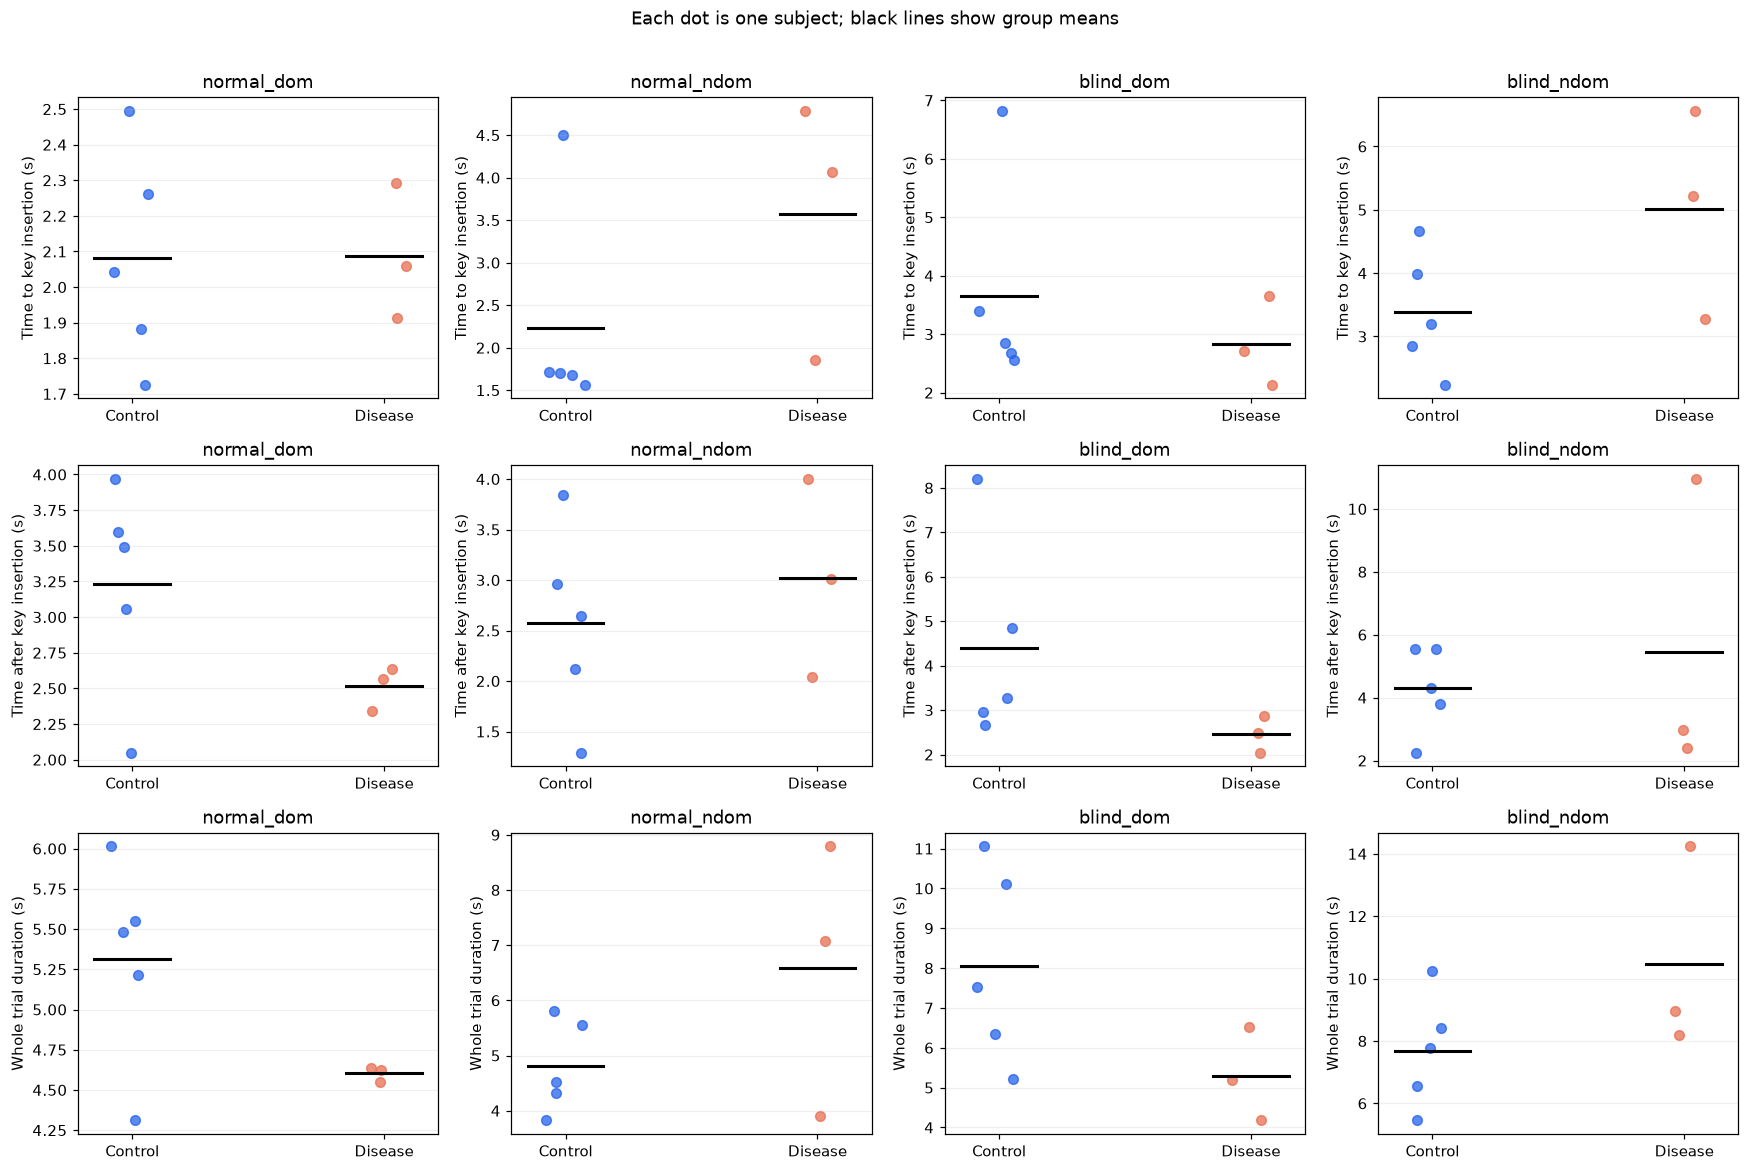

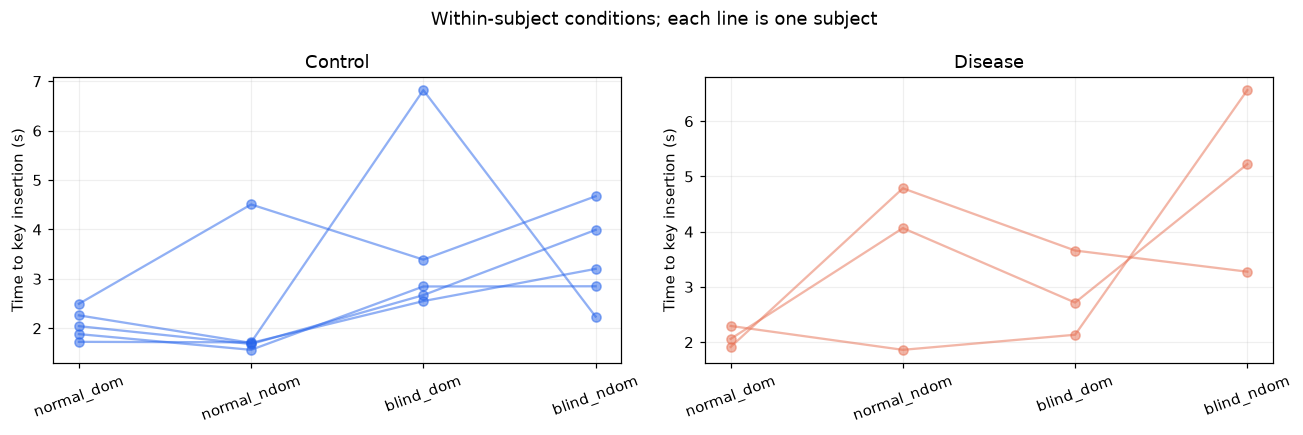

In [5]:
analysis_trials = trial_metrics.copy()
# Manual timing can be usable even when hand landmarks fail QC.
for metric in OUTCOMES:
    if metric not in TASK_OUTCOMES:
        analysis_trials.loc[~trial_metrics.analysis_eligible, metric] = float("nan")
valid_timing = (analysis_trials.status == "completed") & (analysis_trials.annotation_status == "annotated") & (analysis_trials.error == "")
analysis_trials["analysis_eligible"] = analysis_trials.analysis_eligible | valid_timing
if SUCCESSFUL_TASKS_ONLY:
    analysis_trials.loc[analysis_trials.task_outcome != "success", "analysis_eligible"] = False
subjects = subject_summary(analysis_trials, metrics=OUTCOMES)
descriptives = descriptive_statistics(subjects, metrics=OUTCOMES)
display(subjects)
display(descriptives)
if not subjects.empty:
    display(subjects.groupby("group").subject_name.nunique().rename("unique_subjects"))
    display(subjects.pivot(index=["subject_name", "group"], columns="experiment_type", values="trial_count").fillna(0))
    distribution_figure = plot_group_distributions(subjects, metrics=OUTCOMES)
    display_figure_once(distribution_figure)
    plt.close("all")
    paired_figure = plot_paired_conditions(subjects, metric=OUTCOMES[0])
    display_figure_once(paired_figure)
    plt.close("all")
else:
    print("Group summaries need eligible, annotated trials with control/disease labels. Use the replay section to annotate, then rerun from metrics.")


## 4. Control vs disease, separately by condition

Welch's two-sided t-test compares independent **subject** means and allows unequal group variances. The effect direction is **disease minus control**. Results include a 95% CI for the mean difference and Hedges' g (approximate small-sample correction). Mann–Whitney is a separate sensitivity analysis of distributions; it is not automatically a median test. Small samples use the exact method without ties; small tied samples use reproducible permutations (up to 9,999); otherwise an asymptotic test is used. The chosen method is reported. See [SciPy Mann–Whitney methods](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).

Holm correction spans all four conditions and all selected outcomes, separately for each test family. Unavailable tests remain NaN. At least two subjects per group are required; this is a computational minimum, not a sample-size recommendation. Small cohorts give unstable estimates; assess distributions and study design before inference. Choose outcomes before inspecting p-values. No automatic normality-test-based test selection is used. See [SciPy Welch test and CI](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html).


In [6]:
between_groups = compare_groups(subjects, metrics=OUTCOMES)
display(between_groups)


,experiment_type,metric,n_control,n_disease,difference_disease_minus_control,ci_low,ci_high,hedges_g,p_welch,p_mannwhitney,mannwhitney_method,note,p_welch_holm,p_mannwhitney_holm
0,normal_dom,time_to_key_seconds,5,3,0.007124,-0.424405,0.438653,0.022750,0.968973,0.785714,exact,Small sample; results are exploratory,1.000000,1.000000
1,normal_dom,post_key_duration_seconds,5,3,-0.717477,-1.621908,0.186953,-1.025563,0.095054,0.250000,exact,Small sample; results are exploratory,0.950539,1.000000
2,normal_dom,recording_duration_seconds,5,3,-0.710354,-1.490441,0.069734,-1.199239,0.064923,0.250000,exact,Small sample; results are exploratory,0.779076,1.000000
3,normal_ndom,time_to_key_seconds,5,3,1.336613,-1.668015,4.341241,0.853997,0.276236,0.142857,exact,Small sample; results are exploratory,1.000000,1.000000
4,normal_ndom,post_key_duration_seconds,5,3,0.443211,-1.489137,2.375559,0.401039,0.564361,0.571429,exact,Small sample; results are exploratory,1.000000,1.000000
5,normal_ndom,recording_duration_seconds,5,3,1.779824,-3.903465,7.463112,0.974463,0.339526,0.392857,exact,Small sample; results are exploratory,1.000000,1.000000
6,blind_dom,time_to_key_seconds,5,3,-0.818852,-3.091227,1.453523,-0.464218,0.408515,0.785714,exact,Small sample; results are exploratory,1.000000,1.000000
7,blind_dom,post_key_duration_seconds,5,3,-1.933385,-4.752280,0.885510,-0.890622,0.133448,0.071429,exact,Small sample; results are exploratory,1.000000,0.857143
8,blind_dom,recording_duration_seconds,5,3,-2.752236,-5.936455,0.431982,-1.124230,0.078668,0.142857,exact,Small sample; results are exploratory,0.865351,1.000000
9,blind_ndom,time_to_key_seconds,5,3,1.630034,-1.815557,5.075624,1.149491,0.222343,0.142857,exact,Small sample; results are exploratory,1.000000,1.000000


## 5. Paired condition changes and group differences in those changes

Within each group, compare blind minus normal separately for dominant and nondominant trials, and nondominant minus dominant separately for normal and blind trials. Only subjects with both measurements enter a contrast. Paired t-tests use one difference per subject and have Holm adjustment across all requested contrasts/outcomes/groups.

The second table compares these **subject-level changes** between disease and control using Welch tests (difference of differences). This explores group-by-condition effects without pretending repeated conditions are independent. Its Holm correction is a separate family spanning all contrasts/outcomes. These contrasts are not a full mixed-effects factorial model and do not adjust for age, medication, task duration, or other covariates.


In [7]:
paired_effects, change_group_differences = paired_condition_effects(subjects, metrics=OUTCOMES)
display(paired_effects)
display(change_group_differences)


,metric,contrast,group,n_pairs,mean_change,ci_low,ci_high,p_paired,note,p_paired_holm
0,time_to_key_seconds,blind_minus_normal_dom,control,5,1.574037,-0.891808,4.039883,0.151033,,1.000000
1,time_to_key_seconds,blind_minus_normal_dom,disease,3,0.748062,-1.625727,3.121851,0.307928,,1.000000
2,time_to_key_seconds,blind_minus_normal_ndom,control,5,1.156314,0.108629,2.203999,0.037500,,0.862502
3,time_to_key_seconds,blind_minus_normal_ndom,disease,3,1.449735,-6.290977,9.190446,0.504923,,1.000000
4,time_to_key_seconds,ndom_minus_dom_normal,control,5,0.152729,-1.160247,1.465706,0.762900,,1.000000
5,time_to_key_seconds,ndom_minus_dom_normal,disease,3,1.482218,-2.774427,5.738863,0.272796,,1.000000
6,time_to_key_seconds,ndom_minus_dom_blind,control,5,-0.264994,-3.335710,2.805721,0.822418,,1.000000
7,time_to_key_seconds,ndom_minus_dom_blind,disease,3,2.183891,-3.832115,8.199897,0.258712,,1.000000
8,post_key_duration_seconds,blind_minus_normal_dom,control,5,1.162381,-1.298530,3.623292,0.259926,,1.000000
9,post_key_duration_seconds,blind_minus_normal_dom,disease,3,-0.053526,-0.703778,0.596726,0.757063,,1.000000


,metric,contrast,n_control,n_disease,difference_disease_minus_control,ci_low,ci_high,hedges_g,p_welch,p_mannwhitney,mannwhitney_method,note,p_welch_holm
0,time_to_key_seconds,blind_minus_normal_dom,5,3,-0.825976,-3.392751,1.740800,-0.419340,0.459993,0.785714,exact,Small sample; results are exploratory,1.00000
1,time_to_key_seconds,blind_minus_normal_ndom,5,3,0.293421,-7.028231,7.615072,0.132444,0.886770,1.000000,exact,Small sample; results are exploratory,1.00000
2,time_to_key_seconds,ndom_minus_dom_normal,5,3,1.329489,-2.199656,4.858633,0.880434,0.313656,0.571429,exact,Small sample; results are exploratory,1.00000
3,time_to_key_seconds,ndom_minus_dom_blind,5,3,2.448885,-2.320568,7.218338,0.867016,0.235105,0.392857,exact,Small sample; results are exploratory,1.00000
4,post_key_duration_seconds,blind_minus_normal_dom,5,3,-1.215907,-3.659955,1.228140,-0.650535,0.244080,0.392857,exact,Small sample; results are exploratory,1.00000
5,post_key_duration_seconds,blind_minus_normal_ndom,5,3,0.712267,-7.919261,9.343795,0.232962,0.788956,0.785714,exact,Small sample; results are exploratory,1.00000
6,post_key_duration_seconds,ndom_minus_dom_normal,5,3,1.160688,-0.500701,2.822078,1.149804,0.129523,0.142857,exact,Small sample; results are exploratory,1.00000
7,post_key_duration_seconds,ndom_minus_dom_blind,5,3,3.088863,-6.594045,12.771770,0.884380,0.351757,0.392857,exact,Small sample; results are exploratory,1.00000
8,recording_duration_seconds,blind_minus_normal_dom,5,3,-2.041883,-5.096750,1.012984,-0.883374,0.153015,0.250000,exact,Small sample; results are exploratory,1.00000
9,recording_duration_seconds,blind_minus_normal_ndom,5,3,1.005688,-3.911770,5.923145,0.475475,0.559176,0.392857,exact,Small sample; results are exploratory,1.00000


## 6. Replay hand landmarks and inspect individual trials

Select a trial and click **Load replay**. Play/pause and the slider follow recording time; rotate/zoom the view with the mouse. Frames are capped to limit notebook size, and missing detections are blanked rather than interpolated. The skeleton shows 21 landmarks with hand connections; z is estimated wrist-relative depth, so this is not a measured physical 3D scene. Anatomical labels are used when available; legacy detection indices remain explicitly unidentified.

The plots below the replay show the selected task hand's relative trajectory, pinch distance, and speed. If metric configuration is missing, replay still works. All JavaScript is embedded locally; no data or animation requires a network service.

The animation highlights key insertion in gold, labels the event time, marks it on the time slider, and provides a **Key in lock** jump button. Time-series plots show a vertical event line; the trajectory marks the selected fingertip at that time when detections are available. These indicate event timing, not a measured key/object location.

The review controls contain just the insertion time and notes. Success is assumed. Correct the time, click **Save event time**, reload the replay, and rerun analysis cells to update results.


In [8]:
# Retire the old widget/view before creating a replacement.
if "trial_review_widget" in globals():
    trial_review_widget.close()
trial_review_widget = review_widget(
    inventory, hand_selections=hand_selections,
    allow_legacy=ALLOW_LEGACY_HAND_INDEX, legacy_image_size=LEGACY_IMAGE_SIZE,
    min_confidence=MIN_HANDEDNESS_CONFIDENCE, max_gap_seconds=MAX_DERIVATIVE_GAP_SECONDS,
)
display(trial_review_widget)


## 7. Export tables and analysis configuration

Exports go to `analysis_exports/` beside `data/`; acquisition CSVs are preserved. Re-running replaces these review exports. They contain participant names, so treat them like the source data. No example/synthetic observations are mixed into study results.


In [9]:
if not inventory.empty:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    tables = {
        "inventory": inventory, "trial_metrics": trial_metrics, "subject_metrics": subjects,
        "descriptives": descriptives, "group_comparisons": between_groups,
        "paired_effects": paired_effects, "group_change_comparisons": change_group_differences,
        "whole_trial_subject_metrics": whole_trial_subjects,
        "whole_trial_descriptives": whole_trial_descriptives,
        "whole_trial_group_comparisons": whole_trial_comparisons,
        "overall_subject_metrics": overall_subjects,
        "overall_descriptives": overall_descriptives,
        "overall_group_comparisons": overall_comparisons,
    }
    for name, table in tables.items():
        table.to_csv(EXPORT_DIR / f"{name}.csv", index=False)
    if not subjects.empty:
        distribution_figure.savefig(EXPORT_DIR / "group_distributions.png", dpi=200, bbox_inches="tight")
        distribution_figure.savefig(EXPORT_DIR / "group_distributions.pdf", bbox_inches="tight")
        paired_figure.savefig(EXPORT_DIR / "paired_conditions.png", dpi=200, bbox_inches="tight")
    configuration = {
        "data_dir": str(DATA_DIR), "outcomes": OUTCOMES, "whole_trial_outcomes": WHOLE_TRIAL_OUTCOMES,
        "dominant_hands": DOMINANT_HANDS, "hand_selections": hand_selections,
        "allow_legacy_hand_index": ALLOW_LEGACY_HAND_INDEX,
        "legacy_image_size": LEGACY_IMAGE_SIZE, "min_frames": MIN_FRAMES,
        "min_coverage": MIN_COVERAGE, "min_duration_seconds": MIN_DURATION_SECONDS,
        "min_handedness_confidence": MIN_HANDEDNESS_CONFIDENCE,
        "max_derivative_gap_seconds": MAX_DERIVATIVE_GAP_SECONDS,
        "successful_tasks_only": SUCCESSFUL_TASKS_ONLY, "min_rest_phase_frames": MIN_REST_PHASE_FRAMES,
    }
    (EXPORT_DIR / "configuration.json").write_text(json.dumps(configuration, indent=2) + "\n")
    print(f"Exported tables, figures, and configuration to {EXPORT_DIR}")
else:
    print("No acquired data to export yet.")


Exported tables, figures, and configuration to /home/jakub/Projects/proj/analysis_exports
